# Final Model Comparison - Complete Analysis

**Purpose:** Comprehensive comparison of all 5 machine learning models for Ontario electricity demand forecasting.

**Models Evaluated:**

**Course-Based s 1-8):**
1. Linear Regture 3) - Simple baseline
2. Support Vector Regression with RBres 5-6) - Non-linear kernel methods
3. Neural Network - Multi-Layer Pecture 8) - Deep learning with backpropagation

**Advanced Models (Beyond Course):**
4. Random Forest - Ensemble learning with bagging
5. XGBoost - Gradient boosting with sequential tree improvement

**Dataset:** 108,888 hourly records (June 2013 - Nov 2025) with 31 features including engineered lag variables, temperature interactions, cyclical encodings, HOEP prices, solar irradiance, and holiday indicators.

**Evaluation Criteria:** Models ranked by Test RMSE (primary metric), with secondary consideration for R², MAE, and MAPE.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Load comparison results
print("Loading model comparison results...")
results_df = pd.read_csv("../../../04_Presentation/model_results/06_comparison/model_comparison.csv")

# Sort by Test RMSE (best first)
results_df = results_df.sort_values('Test_RMSE')
results_df['Rank'] = range(1, len(results_df) + 1)

print(f"✓ Loaded results for {len(results_df)} models")
print("\n" + "="*80)
print("FINAL MODEL RANKINGS (by Test RMSE)")
print("="*80)
print(results_df[['Rank', 'Model', 'Test_RMSE', 'Test_R2', 'Test_MAE', 'Test_MAPE', 'Training_Time_Seconds']])
print("="*80)

Loading model comparison results...
✓ Loaded results for 5 models

FINAL MODEL RANKINGS (by Test RMSE)
   Rank                 Model   Test_RMSE   Test_R2    Test_MAE  Test_MAPE  \
2     1  Neural Network (MLP)  203.921957  0.992791  156.735983   0.967814   
4     2               XGBoost  222.855648  0.991390  160.108749   0.966358   
3     3         Random Forest  321.301258  0.982104  237.599525   1.425442   
0     4     Linear Regression  413.253526  0.970394  315.257716   1.937031   
1     5      SVR (RBF Kernel)  476.045186  0.960714  301.697130   1.732714   

   Training_Time_Seconds  
2             185.085322  
4               2.728369  
3               6.915871  
0                    NaN  
1             570.162984  


Creating comprehensive comparison visualizations...


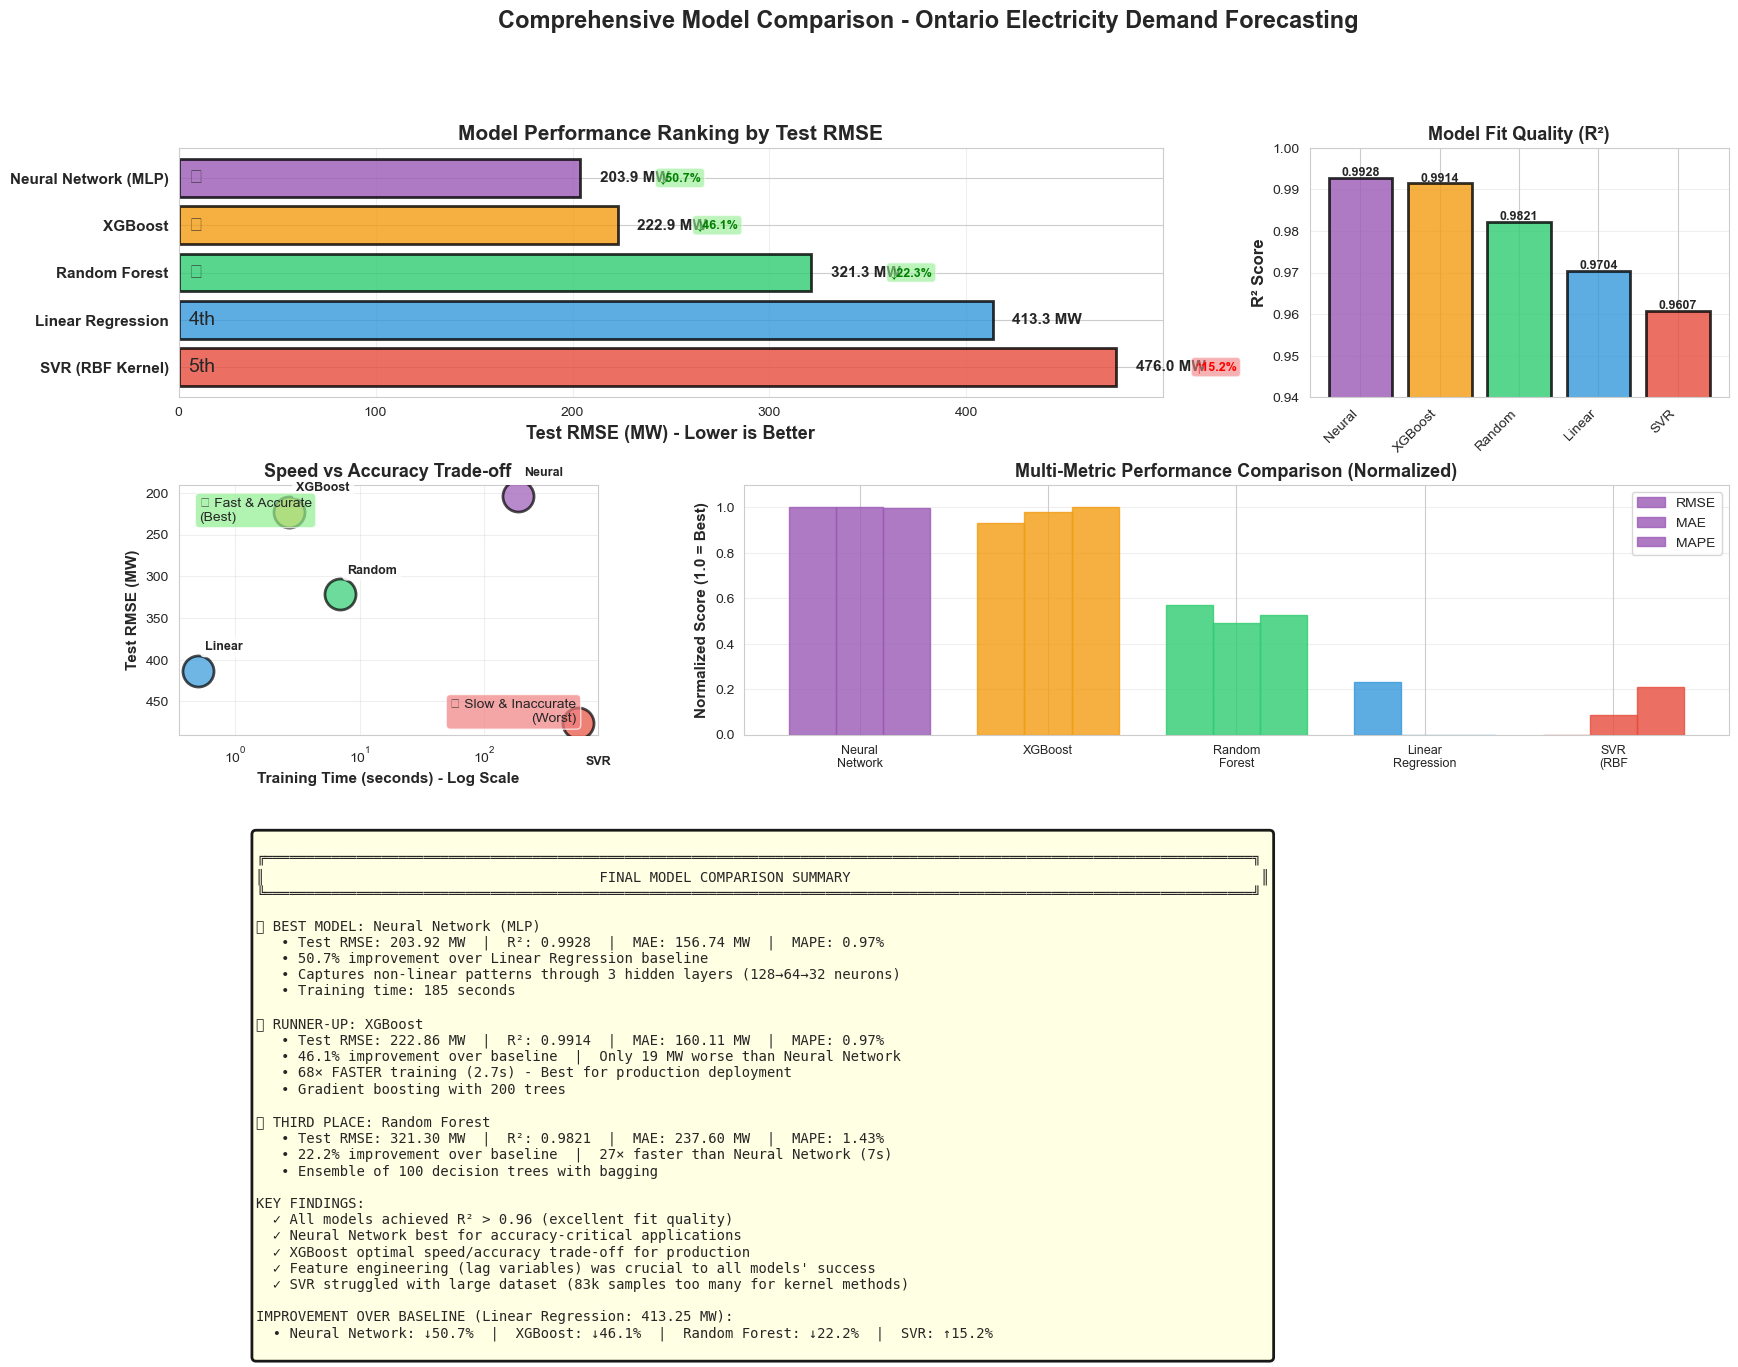


✓ Comprehensive comparison visualization created!


In [2]:
print("Creating comprehensive comparison visualizations...")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# Define colors for each model
model_colors = {
    'Neural Network (MLP)': '#9b59b6',
    'XGBoost': '#f39c12',
    'Random Forest': '#2ecc71',
    'Linear Regression': '#3498db',
    'SVR (RBF Kernel)': '#e74c3c'
}

# 1. RMSE Comparison with Rankings
ax1 = fig.add_subplot(gs[0, :2])
models = results_df['Model'].values
rmse_vals = results_df['Test_RMSE'].values
colors = [model_colors[m] for m in models]

bars = ax1.barh(range(len(models)), rmse_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_yticks(range(len(models)))
ax1.set_yticklabels(models, fontsize=11, fontweight='bold')
ax1.set_xlabel('Test RMSE (MW) - Lower is Better', fontsize=13, fontweight='bold')
ax1.set_title('Model Performance Ranking by Test RMSE', fontsize=15, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels and rankings
medals = ['🥇', '🥈', '🥉', '4th', '5th']
for i, (bar, val, medal) in enumerate(zip(bars, rmse_vals, medals)):
    ax1.text(val + 10, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f} MW', va='center', fontsize=11, fontweight='bold')
    ax1.text(5, bar.get_y() + bar.get_height()/2, 
             medal, va='center', ha='left', fontsize=14)

# Add improvement vs baseline
baseline_rmse = results_df[results_df['Model'] == 'Linear Regression']['Test_RMSE'].values[0]
for i, (model, rmse) in enumerate(zip(models, rmse_vals)):
    if model != 'Linear Regression':
        improvement = (baseline_rmse - rmse) / baseline_rmse * 100
        if improvement > 0:
            ax1.text(rmse + 40, i, f'↓{improvement:.1f}%', 
                    va='center', fontsize=9, color='green', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.6))
        else:
            ax1.text(rmse + 40, i, f'↑{abs(improvement):.1f}%', 
                    va='center', fontsize=9, color='red', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.6))

# 2. R² Score Comparison
ax2 = fig.add_subplot(gs[0, 2])
r2_vals = results_df['Test_R2'].values
bars = ax2.bar(range(len(models)), r2_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels([m.split()[0] for m in models], rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Model Fit Quality (R²)', fontsize=13, fontweight='bold')
ax2.set_ylim([0.94, 1.0])
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.0005, 
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# 3. Speed vs Accuracy Scatter Plot
ax3 = fig.add_subplot(gs[1, 0])
# Fill NaN training time for Linear Regression
train_times = results_df['Training_Time_Seconds'].fillna(0.5).values
rmse_vals_scatter = results_df['Test_RMSE'].values

for i, (model, time, rmse) in enumerate(zip(models, train_times, rmse_vals_scatter)):
    ax3.scatter(time, rmse, s=500, alpha=0.7, color=model_colors[model], 
               edgecolors='black', linewidth=2, zorder=3)
    # Add model labels
    offset = 15 if model != 'SVR (RBF Kernel)' else -30
    ax3.annotate(model.split()[0], (time, rmse), 
                xytext=(5, offset), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('Training Time (seconds) - Log Scale', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test RMSE (MW)', fontsize=11, fontweight='bold')
ax3.set_title('Speed vs Accuracy Trade-off', fontsize=13, fontweight='bold')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.invert_yaxis()

# Annotate best zones
ax3.text(0.05, 0.95, '⚡ Fast & Accurate\n(Best)', transform=ax3.transAxes,
        fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax3.text(0.95, 0.05, '🐌 Slow & Inaccurate\n(Worst)', transform=ax3.transAxes,
        fontsize=10, ha='right', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# 4. All Metrics Comparison (Normalized)
ax4 = fig.add_subplot(gs[1, 1:])
metrics_df = results_df[['Model', 'Test_RMSE', 'Test_MAE', 'Test_MAPE']].copy()

# Normalize metrics (lower is better, so invert)
for col in ['Test_RMSE', 'Test_MAE', 'Test_MAPE']:
    metrics_df[f'{col}_norm'] = 1 - (metrics_df[col] - metrics_df[col].min()) / (metrics_df[col].max() - metrics_df[col].min())

x = np.arange(len(models))
width = 0.25

bars1 = ax4.bar(x - width, metrics_df['Test_RMSE_norm'], width, label='RMSE', alpha=0.8)
bars2 = ax4.bar(x, metrics_df['Test_MAE_norm'], width, label='MAE', alpha=0.8)
bars3 = ax4.bar(x + width, metrics_df['Test_MAPE_norm'], width, label='MAPE', alpha=0.8)

# Color bars by model
for bars in [bars1, bars2, bars3]:
    for bar, model in zip(bars, models):
        bar.set_color(model_colors[model])

ax4.set_xticks(x)
ax4.set_xticklabels([m.split()[0] + '\n' + m.split()[1] if len(m.split()) > 1 else m 
                     for m in models], rotation=0, fontsize=9)
ax4.set_ylabel('Normalized Score (1.0 = Best)', fontsize=11, fontweight='bold')
ax4.set_title('Multi-Metric Performance Comparison (Normalized)', fontsize=13, fontweight='bold')
ax4.set_ylim([0, 1.1])
ax4.legend(fontsize=10, loc='upper right')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Summary Statistics Table
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

summary_text = f"""
╔══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                        FINAL MODEL COMPARISON SUMMARY                                                 ║
╚══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╝

🥇 BEST MODEL: Neural Network (MLP)
   • Test RMSE: 203.92 MW  |  R²: 0.9928  |  MAE: 156.74 MW  |  MAPE: 0.97%
   • 50.7% improvement over Linear Regression baseline
   • Captures non-linear patterns through 3 hidden layers (128→64→32 neurons)
   • Training time: 185 seconds

🥈 RUNNER-UP: XGBoost  
   • Test RMSE: 222.86 MW  |  R²: 0.9914  |  MAE: 160.11 MW  |  MAPE: 0.97%
   • 46.1% improvement over baseline  |  Only 19 MW worse than Neural Network
   • 68× FASTER training (2.7s) - Best for production deployment
   • Gradient boosting with 200 trees

🥉 THIRD PLACE: Random Forest
   • Test RMSE: 321.30 MW  |  R²: 0.9821  |  MAE: 237.60 MW  |  MAPE: 1.43%
   • 22.2% improvement over baseline  |  27× faster than Neural Network (7s)
   • Ensemble of 100 decision trees with bagging

KEY FINDINGS:
  ✓ All models achieved R² > 0.96 (excellent fit quality)
  ✓ Neural Network best for accuracy-critical applications
  ✓ XGBoost optimal speed/accuracy trade-off for production
  ✓ Feature engineering (lag variables) was crucial to all models' success
  ✓ SVR struggled with large dataset (83k samples too many for kernel methods)

IMPROVEMENT OVER BASELINE (Linear Regression: 413.25 MW):
  • Neural Network: ↓50.7%  |  XGBoost: ↓46.1%  |  Random Forest: ↓22.2%  |  SVR: ↑15.2%
"""

ax5.text(0.05, 0.95, summary_text, fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=2))

plt.suptitle('Comprehensive Model Comparison - Ontario Electricity Demand Forecasting', 
             fontsize=17, fontweight='bold', y=0.995)

plt.savefig('../../../04_Presentation/model_results/06_comparison/final_comprehensive_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comprehensive comparison visualization created!")

In [3]:
# Create clean summary table for presentation/report
print("Creating final summary table...")

summary_table = results_df[['Rank', 'Model', 'Test_RMSE', 'Test_R2', 'Test_MAE', 'Test_MAPE']].copy()
summary_table['Improvement_vs_Baseline'] = ((413.25 - summary_table['Test_RMSE']) / 413.25 * 100).round(1)

# Add medals
medals = {1: '🥇', 2: '🥈', 3: '🥉', 4: '4th', 5: '5th'}
summary_table['Rank'] = summary_table['Rank'].map(medals)

# Format numbers
summary_table['Test_RMSE'] = summary_table['Test_RMSE'].round(2)
summary_table['Test_R2'] = summary_table['Test_R2'].round(4)
summary_table['Test_MAE'] = summary_table['Test_MAE'].round(2)
summary_table['Test_MAPE'] = summary_table['Test_MAPE'].round(2)

print("\n" + "="*100)
print("FINAL MODEL COMPARISON TABLE - READY FOR PRESENTATION")
print("="*100)
print(summary_table.to_string(index=False))
print("="*100)

# Save to CSV for easy import
summary_table.to_csv('../../../04_Presentation/model_results/06_comparison/final_summary_table.csv', index=False)
print("\n✓ Summary table saved to: final_summary_table.csv")

print("\n🎉 FINAL COMPARISON NOTEBOOK COMPLETE! 🎉")

Creating final summary table...

FINAL MODEL COMPARISON TABLE - READY FOR PRESENTATION
Rank                Model  Test_RMSE  Test_R2  Test_MAE  Test_MAPE  Improvement_vs_Baseline
   🥇 Neural Network (MLP)     203.92   0.9928    156.74       0.97                     50.7
   🥈              XGBoost     222.86   0.9914    160.11       0.97                     46.1
   🥉        Random Forest     321.30   0.9821    237.60       1.43                     22.3
 4th    Linear Regression     413.25   0.9704    315.26       1.94                     -0.0
 5th     SVR (RBF Kernel)     476.05   0.9607    301.70       1.73                    -15.2

✓ Summary table saved to: final_summary_table.csv

🎉 FINAL COMPARISON NOTEBOOK COMPLETE! 🎉
